# OptiCrop – Smart Agricultural Production Optimization Engine

### Machine Learning Based Crop Recommendation System

## Import Required Libraries

In [1]:
# ==========================================================
# Import Required Libraries
# ==========================================================

# Library for data manipulation and analysis
import pandas as pd

# Library for numerical computations
import numpy as np

# Libraries for data visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Library for machine learning
from sklearn.model_selection import train_test_split
from sklearn.cluster import KMeans
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix

# Ignore warnings
import warnings
warnings.filterwarnings("ignore")

## Load the Agricultural Dataset

In [2]:
# ==========================================================
# Load the Crop Recommendation Dataset
# ==========================================================

# Read the dataset from CSV file
df = pd.read_csv("../dataset/Crop_recommendation.csv")

## Display the First Five Records of the Dataset

In [3]:
# ==========================================================
# Display the First Five Records
# ==========================================================

# Display the first five rows of the dataset
df.head()

,N,P,K,temperature,humidity,ph,rainfall,label
0,90,42,43,20.879744,82.002744,6.502985,202.935536,rice
1,85,58,41,21.770462,80.319644,7.038096,226.655537,rice
2,60,55,44,23.004459,82.320763,7.840207,263.964248,rice
3,74,35,40,26.491096,80.158363,6.980401,242.864034,rice
4,78,42,42,20.130175,81.604873,7.628473,262.717340,rice


## Display Dataset Shape

In [4]:
# ==========================================================
# Display Dataset Shape
# ==========================================================

# Display the number of rows and columns
df.shape

(2200, 8)

## Display Dataset Information

In [5]:
# ==========================================================
# Display Dataset Information
# ==========================================================

# Display dataset information
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2200 entries, 0 to 2199
Data columns (total 8 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   N            2200 non-null   int64  
 1   P            2200 non-null   int64  
 2   K            2200 non-null   int64  
 3   temperature  2200 non-null   float64
 4   humidity     2200 non-null   float64
 5   ph           2200 non-null   float64
 6   rainfall     2200 non-null   float64
 7   label        2200 non-null   object 
dtypes: float64(4), int64(3), object(1)
memory usage: 137.6+ KB


## Display Statistical Summary

In [6]:
# ==========================================================
# Display Statistical Summary
# ==========================================================

# Display statistical summary of the dataset
df.describe()

,N,P,K,temperature,humidity,ph,rainfall
count,2200.000000,2200.000000,2200.000000,2200.000000,2200.000000,2200.000000,2200.000000
mean,50.551818,53.362727,48.149091,25.616244,71.481779,6.469480,103.463655
std,36.917334,32.985883,50.647931,5.063749,22.263812,0.773938,54.958389
min,0.000000,5.000000,5.000000,8.825675,14.258040,3.504752,20.211267
25%,21.000000,28.000000,20.000000,22.769375,60.261953,5.971693,64.551686
50%,37.000000,51.000000,32.000000,25.598693,80.473146,6.425045,94.867624
75%,84.250000,68.000000,49.000000,28.561654,89.948771,6.923643,124.267508
max,140.000000,145.000000,205.000000,43.675493,99.981876,9.935091,298.560117


## Check Missing Values

In [7]:
# ==========================================================
# Check Missing Values
# ==========================================================

# Check for missing values
df.isnull().sum()

N              0
P              0
K              0
temperature    0
humidity       0
ph             0
rainfall       0
label          0
dtype: int64

## Univariate Analysis

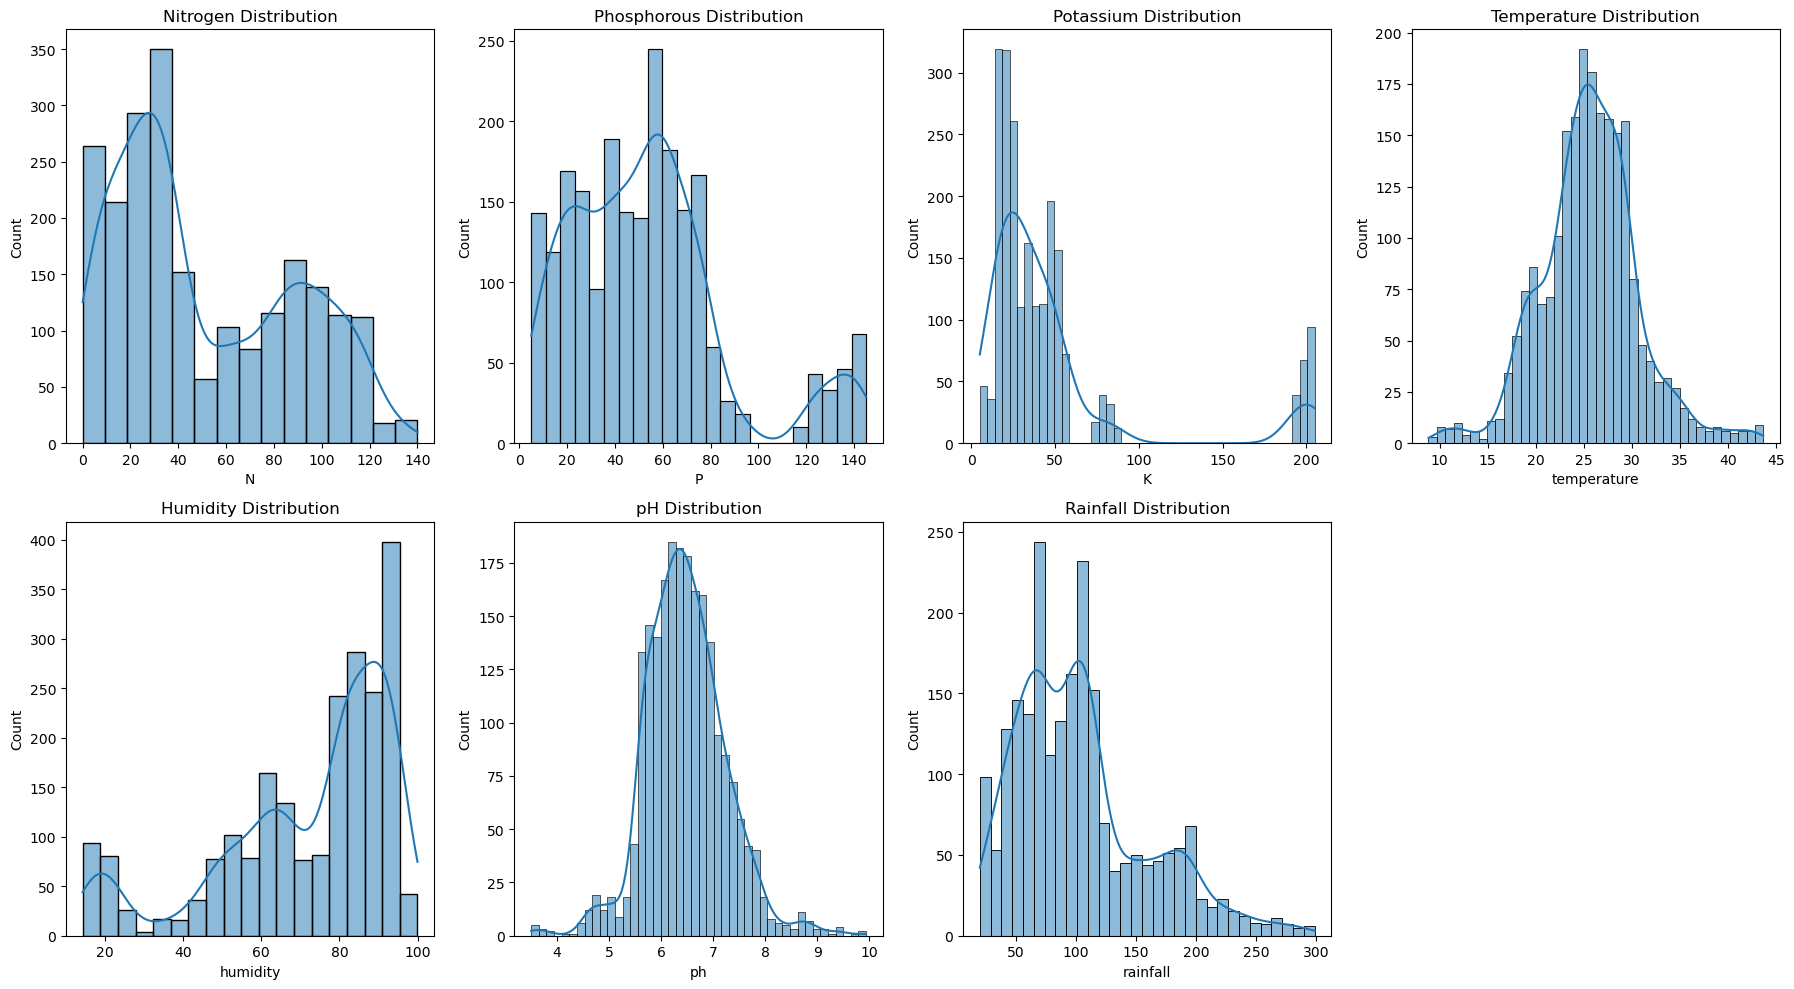

In [8]:
# ==========================================================
# Univariate Analysis
# ==========================================================

# Display the distribution of numerical features

plt.figure(figsize=(18,10))

plt.subplot(2,4,1)
sns.histplot(df['N'], kde=True)
plt.title("Nitrogen Distribution")

plt.subplot(2,4,2)
sns.histplot(df['P'], kde=True)
plt.title("Phosphorous Distribution")

plt.subplot(2,4,3)
sns.histplot(df['K'], kde=True)
plt.title("Potassium Distribution")

plt.subplot(2,4,4)
sns.histplot(df['temperature'], kde=True)
plt.title("Temperature Distribution")

plt.subplot(2,4,5)
sns.histplot(df['humidity'], kde=True)
plt.title("Humidity Distribution")

plt.subplot(2,4,6)
sns.histplot(df['ph'], kde=True)
plt.title("pH Distribution")

plt.subplot(2,4,7)
sns.histplot(df['rainfall'], kde=True)
plt.title("Rainfall Distribution")

plt.tight_layout()
plt.show()

## Crop Distribution Analysis

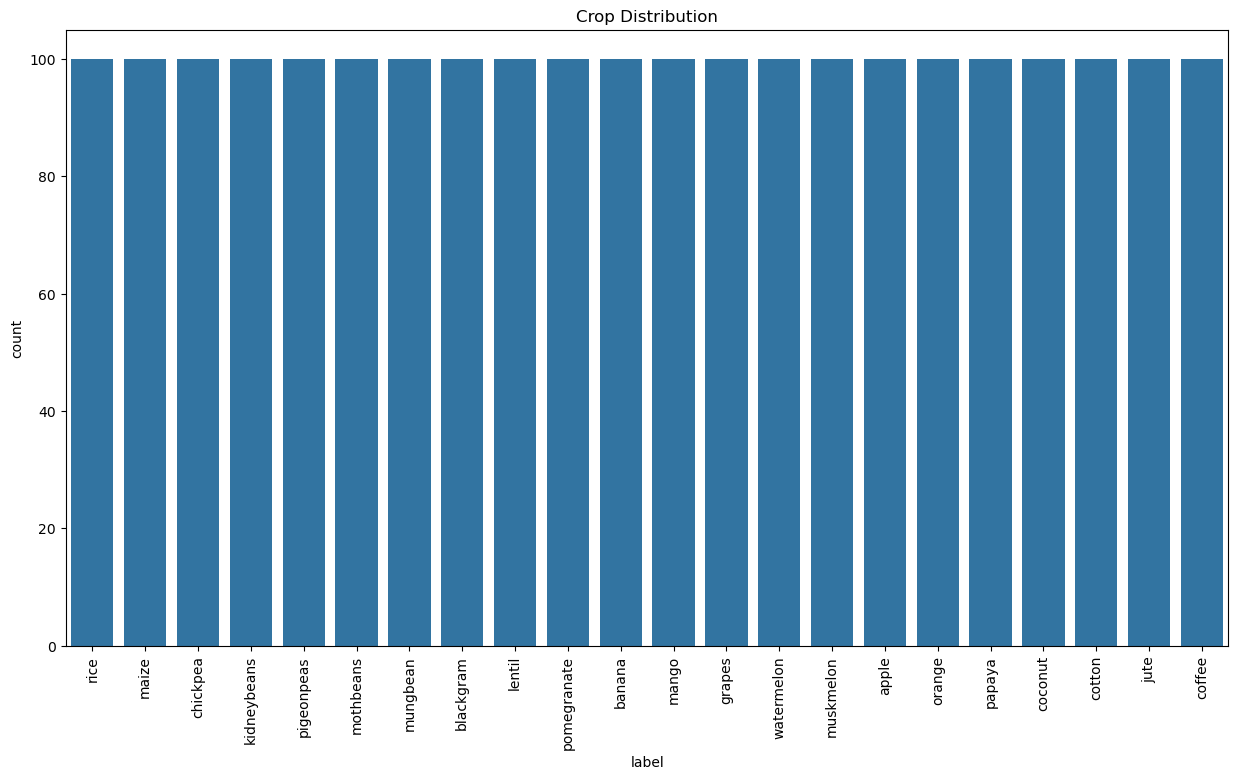

In [9]:
# ==========================================================
# Crop Distribution Analysis
# ==========================================================

plt.figure(figsize=(15,8))

sns.countplot(
    data=df,
    x='label',
    order=df['label'].value_counts().index
)

plt.xticks(rotation=90)
plt.title("Crop Distribution")
plt.show()

## Bivariate Analysis

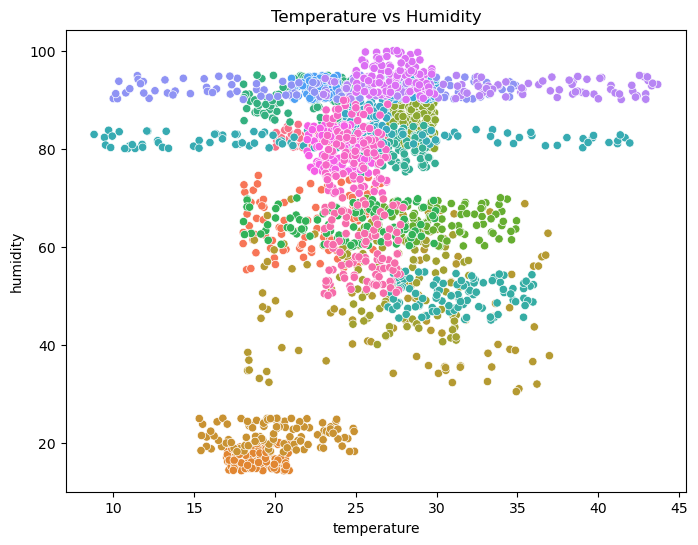

In [10]:
# ==========================================================
# Bivariate Analysis
# ==========================================================

# Scatter Plot between Temperature and Humidity

plt.figure(figsize=(8,6))

sns.scatterplot(
    data=df,
    x='temperature',
    y='humidity',
    hue='label',
    legend=False
)

plt.title("Temperature vs Humidity")
plt.show()

## Relationship Between Humidity and Crop Labels

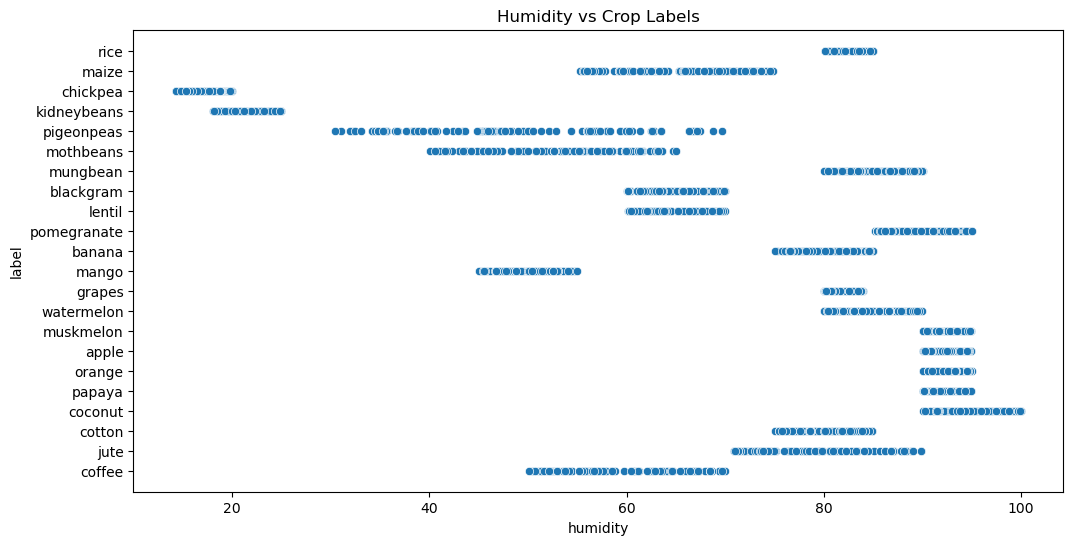

In [11]:
# ==========================================================
# Humidity vs Crop Labels
# ==========================================================

plt.figure(figsize=(12,6))

sns.scatterplot(
    data=df,
    x='humidity',
    y='label'
)

plt.title("Humidity vs Crop Labels")
plt.show()

## Multivariate Analysis

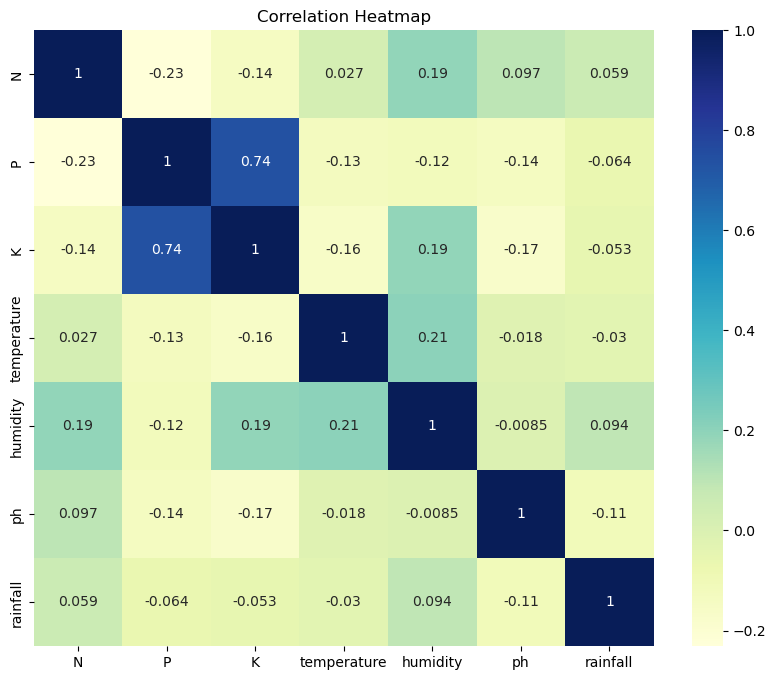

In [12]:
# ==========================================================
# Correlation Heatmap
# ==========================================================

plt.figure(figsize=(10,8))

sns.heatmap(
    df.corr(numeric_only=True),
    annot=True,
    cmap='YlGnBu'
)

plt.title("Correlation Heatmap")
plt.show()

## Check Dataset for Missing Values

In [13]:
# ==========================================================
# Check Missing Values
# ==========================================================

df.isnull().sum()

N              0
P              0
K              0
temperature    0
humidity       0
ph             0
rainfall       0
label          0
dtype: int64

## Outlier Detection Using Boxplots

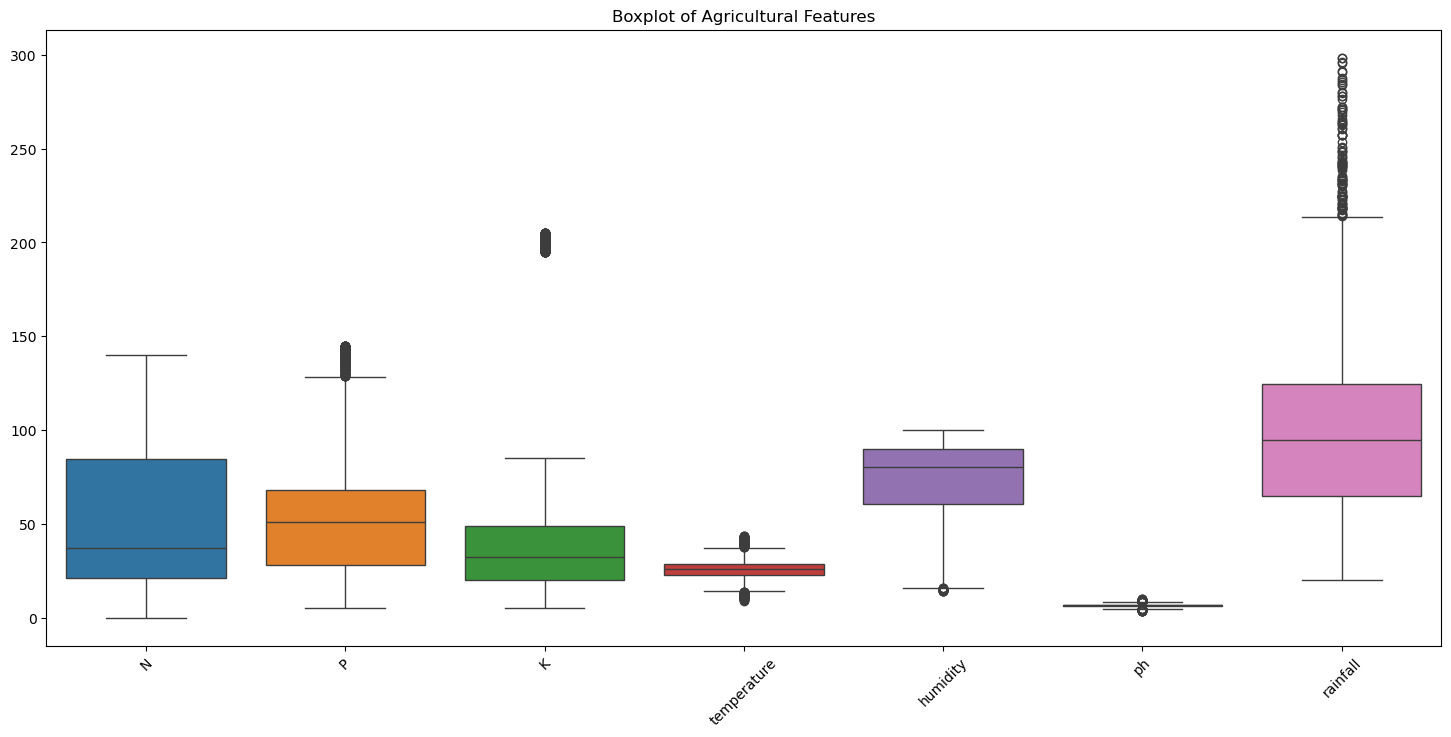

In [14]:
# ==========================================================
# Detect Outliers
# ==========================================================

plt.figure(figsize=(18,8))

sns.boxplot(data=df)

plt.xticks(rotation=45)
plt.title("Boxplot of Agricultural Features")
plt.show()

## Calculate Interquartile Range (IQR)

In [15]:
# ==========================================================
# Calculate IQR
# ==========================================================

Q1 = df['K'].quantile(0.25)
Q3 = df['K'].quantile(0.75)

IQR = Q3 - Q1

Lower_Bound = Q1 - 1.5 * IQR
Upper_Bound = Q3 + 1.5 * IQR

print("Q1 :", Q1)
print("Q3 :", Q3)
print("IQR :", IQR)
print("Lower Bound :", Lower_Bound)
print("Upper Bound :", Upper_Bound)

Q1 : 20.0
Q3 : 49.0
IQR : 29.0
Lower Bound : -23.5
Upper Bound : 92.5


## Remove Outliers

In [16]:
# ==========================================================
# Remove Outliers
# ==========================================================

df = df[(df['K'] >= Lower_Bound) & (df['K'] <= Upper_Bound)]

print("Dataset Shape After Removing Outliers :", df.shape)

Dataset Shape After Removing Outliers : (2000, 8)


## Seasonal Crop Analysis

In [17]:
# ==========================================================
# Seasonal Crop Analysis
# ==========================================================

# Display crops suitable for different seasons

print("Summer Crops")
print(df[(df['temperature'] > 30)]['label'].unique())

print("\nWinter Crops")
print(df[(df['temperature'] < 20)]['label'].unique())

print("\nRainy Season Crops")
print(df[(df['rainfall'] > 200)]['label'].unique())

Summer Crops
['pigeonpeas' 'mothbeans' 'blackgram' 'mango' 'orange' 'papaya']

Winter Crops
['maize' 'chickpea' 'kidneybeans' 'pigeonpeas' 'lentil' 'pomegranate'
 'orange']

Rainy Season Crops
['rice' 'papaya' 'coconut']


## Separate Features and Target Variable

In [18]:
# ==========================================================
# Separate Features and Target Variable
# ==========================================================

# Features
X = df.drop('label', axis=1)

# Target
y = df['label']

print("Shape of Features :", X.shape)
print("Shape of Target :", y.shape)

Shape of Features : (2000, 7)
Shape of Target : (2000,)


## Split Dataset into Training and Testing Sets

In [19]:
# ==========================================================
# Train-Test Split
# ==========================================================

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

print("Training Features :", X_train.shape)
print("Testing Features :", X_test.shape)
print("Training Target :", y_train.shape)
print("Testing Target :", y_test.shape)

Training Features : (1600, 7)
Testing Features : (400, 7)
Training Target : (1600,)
Testing Target : (400,)


## K-Means Clustering using Elbow Method

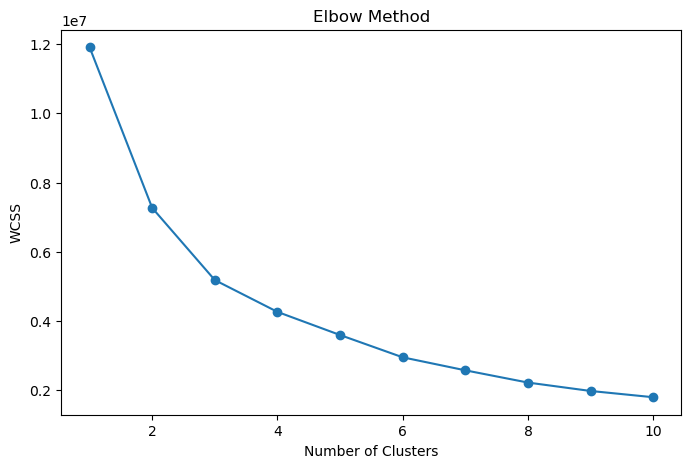

In [22]:
# ==========================================================
# Elbow Method
# ==========================================================
import os

# Limit joblib to one CPU core to avoid WMIC warning on Windows
os.environ["LOKY_MAX_CPU_COUNT"] = "1"
wcss = []

for i in range(1, 11):
    kmeans = KMeans(
        n_clusters=i,
        init='k-means++',
        max_iter=300,
        n_init=10,
        random_state=42
    )

    kmeans.fit(X)
    wcss.append(kmeans.inertia_)

plt.figure(figsize=(8,5))
plt.plot(range(1,11), wcss, marker='o')

plt.title("Elbow Method")
plt.xlabel("Number of Clusters")
plt.ylabel("WCSS")

plt.show()

## Apply K-Means Clustering

In [21]:
# ==========================================================
# K-Means Clustering
# ==========================================================

kmeans = KMeans(
    n_clusters=4,
    random_state=42
)

df['Cluster'] = kmeans.fit_predict(X)

df.head()

,N,P,K,temperature,humidity,ph,rainfall,label,Cluster
0,90,42,43,20.879744,82.002744,6.502985,202.935536,rice,2
1,85,58,41,21.770462,80.319644,7.038096,226.655537,rice,2
2,60,55,44,23.004459,82.320763,7.840207,263.964248,rice,2
3,74,35,40,26.491096,80.158363,6.980401,242.864034,rice,2
4,78,42,42,20.130175,81.604873,7.628473,262.717340,rice,2


## Logistic Regression Model

In [23]:
# ==========================================================
# Build the Logistic Regression Model
# ==========================================================

# Create the Logistic Regression model
model = LogisticRegression(max_iter=1000)

# Train the model
model.fit(X_train, y_train)

LogisticRegression(max_iter=1000)

## Predict Crop Labels

In [24]:
# ==========================================================
# Predict Crop Labels
# ==========================================================

# Predict crop labels using the testing dataset
y_pred = model.predict(X_test)

# Display first 10 predictions
print(y_pred[:10])

['jute' 'kidneybeans' 'muskmelon' 'pomegranate' 'watermelon' 'watermelon'
 'pomegranate' 'cotton' 'jute' 'muskmelon']


## Evaluate the Model Performance

In [25]:
# ==========================================================
# Calculate Model Accuracy
# ==========================================================

from sklearn.metrics import accuracy_score

accuracy = accuracy_score(y_test, y_pred)

print("Model Accuracy :", accuracy)

Model Accuracy : 0.95


## Generate Classification Report

In [26]:
# ==========================================================
# Classification Report
# ==========================================================

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

      banana       1.00      1.00      1.00        15
   blackgram       0.84      0.89      0.86        18
    chickpea       1.00      1.00      1.00        22
     coconut       1.00      1.00      1.00        28
      coffee       1.00      0.96      0.98        24
      cotton       0.90      0.90      0.90        20
        jute       0.80      0.89      0.84        18
 kidneybeans       1.00      1.00      1.00        25
      lentil       0.93      0.88      0.90        16
       maize       0.89      0.89      0.89        18
       mango       1.00      1.00      1.00        19
   mothbeans       0.84      0.84      0.84        25
    mungbean       1.00      1.00      1.00        18
   muskmelon       1.00      1.00      1.00        17
      orange       1.00      1.00      1.00        21
      papaya       0.91      0.91      0.91        23
  pigeonpeas       1.00      1.00      1.00        21
 pomegranate       1.00    

## Generate Confusion Matrix

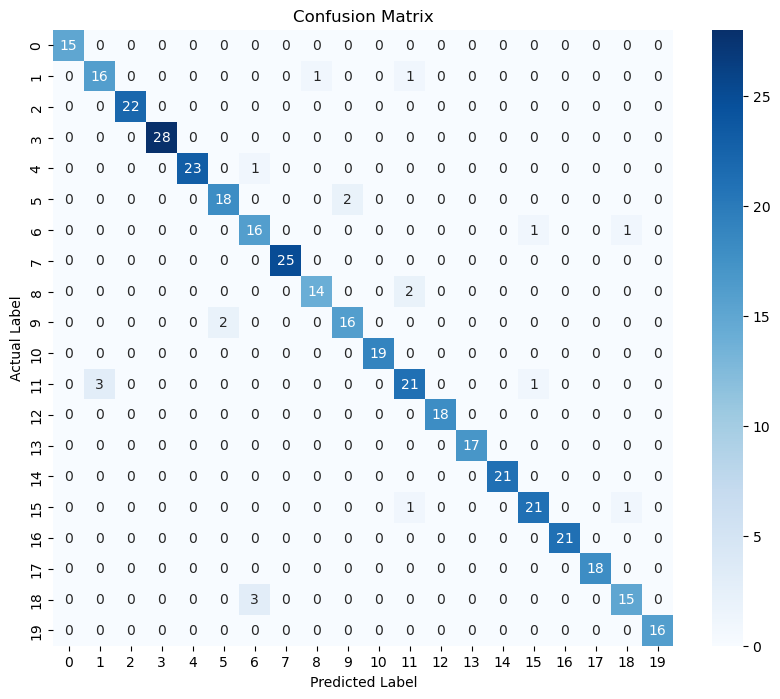

In [27]:
# ==========================================================
# Confusion Matrix
# ==========================================================

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(10,8))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues"
)

plt.title("Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("Actual Label")

plt.show()

## Save the Trained Machine Learning Model

In [28]:
# ==========================================================
# Save the Trained Model
# ==========================================================

import pickle

# Save the trained model
pickle.dump(model, open("../model/crop_model.pkl", "wb"))

print("Model saved successfully.")

Model saved successfully.
